# Metagenomic assembly tutorial



### Data Setup Required:
Before running this notebook, you'll need to create the following data structure in your workspace (most likely is alread there):

```
/biodata/resources/
├── /day2_lab2/
│   ├── raw_reads/
│   │   ├── 25748_R1.fastq.gz
│   │   └── 25748_R2.fastq.gz
│   └── aseembly/
│       ├── contig_demo/
│       └── tmp/
```

### Bash Commands in Jupyter:
- Use `!command` for single bash commands
- Use `%%bash` magic for entire cells of bash code
- All existing `!` commands should work as-is in your devcontainer

In [1]:
import os, glob

# Set up paths for devcontainer environment
workspace_root = "/biodata/resources/day2_lab2"  # or wherever your workspace is mounted
root_dir = workspace_root
py_env = os.path.join(workspace_root, "python_env")  # optional: if you want a specific python env folder

## Setup the environment





In [2]:
# Set up python path if needed
import os, sys
if py_env not in sys.path:
    sys.path.append(py_env)

# In devcontainer, conda/mamba should already be available
# Check if megahit is already installed, if not install it
try:
    import subprocess
    result = subprocess.run(['which', 'megahit'], capture_output=True, text=True)
    if result.returncode != 0:
        print("Installing megahit...")
        !micromamba install -c bioconda megahit -y
    else:
        print("megahit is already available")
except:
    print("Installing megahit...")
    !micromamba install -c bioconda megahit -y

megahit is already available


In [3]:
! which megahit

/opt/conda/bin/megahit


In [4]:
# Install additional Python packages if needed
# In devcontainer, you can use pip or mamba/conda to install packages
# !pip install matplotlib seaborn pandas
# or
# !mamba install matplotlib seaborn pandas -y

In [5]:
# Set up data directories in your workspace
import os

# Data directories - update these paths based on where you place your data
mgx_reads_dir = os.path.join(root_dir, "raw_reads")  # Place your FASTQ files here
contig_demo_dir = os.path.join(root_dir, "assembly", "contig_demo")
contig_demo_tmp_dir = os.path.join(root_dir, "assembly", "tmp")

# Create directories if they don't exist
!mkdir -p {mgx_reads_dir}
!mkdir -p {contig_demo_dir}
!mkdir -p {contig_demo_tmp_dir}

# Check if data directories exist
print(f"MGX reads directory: {mgx_reads_dir}")
!ls -lh {mgx_reads_dir} 2>/dev/null || echo "Directory is empty or doesn't exist - please add your FASTQ files here"

sample_id = "25748"
p1 = os.path.join(mgx_reads_dir, sample_id + "_R1.fastq.gz")
p2 = os.path.join(mgx_reads_dir, sample_id + "_R2.fastq.gz")

print(f"Looking for files:")
print(f"  - {p1}")
print(f"  - {p2}")

MGX reads directory: /biodata/resources/day2_lab2/raw_reads
total 329M
-rw-rw-rw- 1 root root 164M Nov 22  2018 25748_R1.fastq.gz
-rw-rw-rw- 1 root root 166M Nov 22  2018 25748_R2.fastq.gz
Looking for files:
  - /biodata/resources/day2_lab2/raw_reads/25748_R1.fastq.gz
  - /biodata/resources/day2_lab2/raw_reads/25748_R2.fastq.gz


In [6]:
! megahit --help

MEGAHIT v1.2.9

contact: Dinghua Li <voutcn@gmail.com>

Usage:
  megahit [options] {-1 <pe1> -2 <pe2> | --12 <pe12> | -r <se>} [-o <out_dir>]

  Input options that can be specified for multiple times (supporting plain text and gz/bz2 extensions)
    -1                       <pe1>          comma-separated list of fasta/q paired-end #1 files, paired with files in <pe2>
    -2                       <pe2>          comma-separated list of fasta/q paired-end #2 files, paired with files in <pe1>
    --12                     <pe12>         comma-separated list of interleaved fasta/q paired-end files
    -r/--read                <se>           comma-separated list of fasta/q single-end files

Optional Arguments:
  Basic assembly options:
    --min-count              <int>          minimum multiplicity for filtering (k_min+1)-mers [2]
    --k-list                 <int,int,..>   comma-separated list of kmer size
                                            all must be odd, in the range 15-255, inc

# Run megahit


In [7]:
# Run megahit assembly (uncomment to run)
! rm -rf {contig_demo_dir}
! megahit --tmp-dir {contig_demo_tmp_dir} -1 {p1} -2 {p2} -t 4 -m 0.9 -o {contig_demo_dir} --out-prefix {sample_id}

# Path to contigs (either from the run above or pre-existing)
# contig_dir = os.path.join(root_dir, "data", "assembly", "contig_demo")
# contig_dir = contig_demo_dir
# !mkdir -p {contig_dir}

print(f"Looking for contigs in: {contig_demo_dir}")
!ls {contig_demo_dir}/{sample_id}* 2>/dev/null || echo "No contig files found - please run megahit assembly first or place pre-calculated contigs here"

2025-10-06 21:12:39 - MEGAHIT v1.2.9
2025-10-06 21:12:39 - Using megahit_core with POPCNT and BMI2 support
2025-10-06 21:12:39 - Convert reads to binary library
2025-10-06 21:12:44 - b'INFO  sequence/io/sequence_lib.cpp  :   75 - Lib 0 (/biodata/resources/day2_lab2/raw_reads/25748_R1.fastq.gz,/biodata/resources/day2_lab2/raw_reads/25748_R2.fastq.gz): pe, 2813930 reads, 151 max length'
2025-10-06 21:12:44 - b'INFO  utils/utils.h                 :  152 - Real: 4.8964\tuser: 2.7301\tsys: 0.4889\tmaxrss: 182436'
2025-10-06 21:12:44 - k-max reset to: 141 
2025-10-06 21:12:44 - Start assembly. Number of CPU threads 4 
2025-10-06 21:12:44 - k list: 21,29,39,59,79,99,119,141 
2025-10-06 21:12:44 - Memory used: 15095701094
2025-10-06 21:12:44 - Extract solid (k+1)-mers for k = 21 
2025-10-06 21:13:26 - Build graph for k = 21 
2025-10-06 21:13:28 - Assemble contigs from SdBG for k = 21
2025-10-06 21:13:30 - Local assembly for k = 21
2025-10-06 21:13:39 - Extract iterative edges from k = 21 to 29

## Check the output file

In [8]:
! head {contig_demo_dir}/{sample_id}.contigs.fa

>k141_0 flag=0 multi=1.0000 len=335
ATATGTTAATGAAATTGTTGAAACGATACCTGATAGCGAATTCGATGAATTCAGACATCATCGTGGCGCAACATCCTATCATCCAAAAATGATGTTAAAAATCATCTTATATGCATATACTCAATCTGTATTTTCTGGTCGTAGAATAGAAAAATTACTTCATGACAGTATTCGAATGATGTGGTTAGCTCAAGATCAAACACCTTCTTATAAAACTATTAATCGTTTTAGAGTGAATCCTAATACTGATGCGTTAATTGAATCTTTATTTATTCAGTTCCATAGTCAATGTTTAAAGCAAAATCTTATTGATAATAATTCAATTTTTATTGATG
>k141_31 flag=0 multi=306.0000 len=327
TCATCAAACGCTTGCGCTTTCTTATACACGTCTTCAACCTCTTTTAGTAATCCCTCTGTGTCATTACCGTTATACGCACTAGCACTAATAACGGACTGTTCGATTTTTTCGCGATTATTCATTTGTGTCATCCTCCATAAAAATTTTATTGTTTAATTCCATTCCGAATTTAACTCTTTCATCATCGTTACCGAATTTGTTTATTAAATCTTTTTCAACGCTCTTGCAATACCTATCCCATGCGCTTGCTTTCTTCTCCAGTTCTTTGTTACAATCTCGTAACTTCGCTATAACCCCAATAAGCTCATATCGTTGCTTCTTGTACTC
>k141_1 flag=0 multi=1.0000 len=226
ATATGTTAATGAAATTGTTGAAACGATACCTGATAGCGAATTCGATGAATTCAGACATCATCGTGGCGCAACATCCTATCATCCAAAAATGATGTTAAAAATCATCTTATATGCATATACTCAATCTGTATTTTCTGGTCGAAGAATAGAGAAATTACTTCATGACAGTATTCGAATGATGTGGTTAGCTCAAAATCAAACACCTTCTTATAAAACTATTAATCG

### Reminder: fasta format:

*   Commonly used to save sequences [DNA/RNA/Protein]
*   Each sequence is recorded on two lines


> 1.   A header line that starts with **>**, which is the identifier for the sequence
> 2.   A sequence line: recording the sequence associated with the header above (e.g. nucleotides for DNA reads)









In [9]:
# show the first few headers
! grep ">" {contig_demo_dir}/{sample_id}.contigs.fa | head

>k141_0 flag=0 multi=1.0000 len=335
>k141_31 flag=0 multi=306.0000 len=327
>k141_1 flag=0 multi=1.0000 len=226
>k141_32 flag=0 multi=13.0000 len=233
>k141_33 flag=0 multi=3.1649 len=238
>k141_62 flag=0 multi=83.8616 len=1066
>k141_63 flag=0 multi=65.9431 len=422
>k141_2 flag=1 multi=1.0000 len=1113
>k141_64 flag=0 multi=101.8782 len=16486
>k141_65 flag=0 multi=1176.1393 len=3759


## Task 1 (3 min):
How many contigs are assembled?

Hint:


*   **grep** the headers starting with **">"**, remember to add quotation marks to avoid overwrite
*   count with the **wc** commend





In [11]:
#grep ">" {contig_demo_dir}/{sample_id}.contigs.fa | wc -l

## Collect the length of each contigs

In [12]:
def get_length(fp):
  # a list to save the length of each contig
  length_lst = []
  with open(fp,"r") as f:
    # iterate throught each line
    for line in f:
      # collect the lengths from header lines [started with ">"]
          # >k105_1 flag=1 multi=4.0000 len=340\n
      if ">" in line:
        # add the length into the list
        # .strip(): remove the newline character [\n]
          # >k105_1 flag=1 multi=4.0000 len=340
        # .split(): split the string by a pattern
          # len=340
          # 340
        length_lst.append(int(line.strip().split(" ")[-1].split("=")[1]))
  return length_lst

contig_fp = os.path.join(contig_demo_dir,sample_id+".contigs.fa")
length_lst = get_length(contig_fp)
length_lst[:10]
#

[335, 327, 226, 233, 238, 1066, 422, 1113, 16486, 3759]

## Overview of the length distribution of contigs

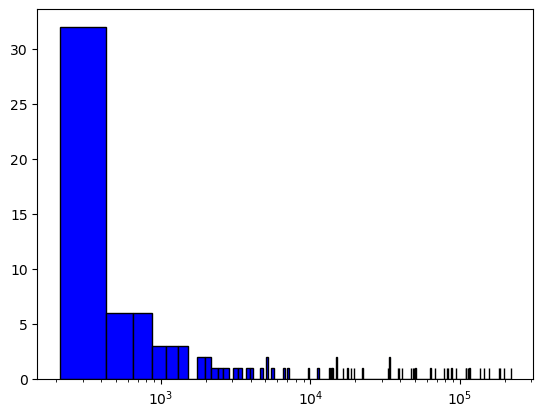

In [13]:
import matplotlib.pyplot as plt
plt.hist(length_lst, color = 'blue', edgecolor = 'black', bins = 1000)
plt.xscale("log")
plt.show()

## Evaluation of the assembly result

Notice that most of the contigs are very short (<1000 bp), which indicates that our assembly is very fragmented

**What is a good sequence assembly?**

Let's start by asking the opposite question: what is a bad assembly?

*   Too fragmented
*   Too long: reads connected directly by head to tail
*   Ideal assembly: A concise set of continuous contigs that explain as much of the input reads as possible.

Commonly used evaluation metrics: N50 and L50


### Calculate the N50


*   Input: a list of contig lengths
*   Output: the N50 values of the assembly
*   Workflow:
> 1. calculate the total length of the contigs
> 2. sort the contig lengths from long to short
> 3. sum up the contig lengths from long to short, until you reach 50% of the total length of all contigs
> 4. return the length of the last visited contig



In [14]:
# a function to calculate the total length of the contigs
def calculate_total_length(length_lst):
  total_length = 0
  for L in length_lst:
    total_length = total_length+L
  return total_length

total_length = calculate_total_length(length_lst)
print("the total length is:",total_length)

# sort the length from short to long
print("before sorting:",length_lst[:10])
length_lst.sort(reverse=True)
print("after sorting:",length_lst[:10])

cur_L = length_lst[0]
cur_sum = cur_L
for next_L in length_lst[1:]:
  # when the length sum of visited contigs reach the half of the total length, current L will the our N50
  if cur_sum>0.5*total_length:
    break
  cur_sum = cur_sum+next_L
  cur_L = next_L
print("N50 is:",cur_L)
#

the total length is: 3030905
before sorting: [335, 327, 226, 233, 238, 1066, 422, 1113, 16486, 3759]
after sorting: [219006, 195658, 185983, 181749, 155536, 143996, 135591, 115768, 115190, 112572]
N50 is: 112572


### Task: Calculate the L50 [5 minutes]

The L50 is defined as the smallest number of contigs whose length sum up to 50% of the total size of all contigs

*   Input: a list of contig lengths
*   Output: :50 values of the assembly
*   Workflow:
> 1. calculate the total length of all contigs together
> 2. sort the contig lengths from long to short
> 3. sum up the contig lengths from long to short, until you reach 50% of the total length of all contigs
> 4. return the total number of visited contigs



### The answer

In [15]:
# a function to calculate the total length of the contigs
def calculate_total_length(length_lst):
  total_length = 0
  for L in length_lst:
    total_length = total_length+L
  return total_length

total_length = calculate_total_length(length_lst)
print("the total length is:",total_length)

# sort the length from short to long
print("before sorting:",length_lst[:10])
length_lst.sort(reverse=True)
print("after sorting:",length_lst[:10])

cur_L = length_lst[0]
cur_idx = 1
cur_sum = cur_L
for next_L in length_lst[1:]:
  # when the length sum of visited contigs reach the half of the total length, current L will the our N50
  if cur_sum>0.5*total_length:
    break
  cur_sum = cur_sum+next_L
  cur_L = next_L
  cur_idx = cur_idx+1
print("L50 is:",cur_idx)
#

the total length is: 3030905
before sorting: [219006, 195658, 185983, 181749, 155536, 143996, 135591, 115768, 115190, 112572]
after sorting: [219006, 195658, 185983, 181749, 155536, 143996, 135591, 115768, 115190, 112572]
L50 is: 10


### Your solution

In [ ]:
# your solution

## Discussion:

What is a good assembly?

*   N50: the larger the better
*   L50: the smaller the better

